In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

nltk.download('stopwords')
STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# -----------------------------
# 2️⃣ Load Full Dataset (Using the provided file path)
# -----------------------------
FILE_PATH = "Reviews_sample.csv"
FILE_SEPARATOR = "\t" # Assuming tab-separated file based on previous interaction

print(f"--- Step 2: Loading Full Dataset from {FILE_PATH} ---")

try:
    # Load the entire file into memory (RAM)
    df = pd.read_csv(FILE_PATH, sep=FILE_SEPARATOR)
except Exception as e:
    # Error handling in case the file is not found or the separator is wrong
    print(f"ERROR: Could not read file '{FILE_PATH}'. Please check file path, file existence, or separator ('{FILE_SEPARATOR}'). Details: {e}")
    exit()

# Drop rows where 'Text' or 'Score' is missing
df.dropna(subset=['Text', 'Score'], inplace=True)
print(f"✅ Full dataset loaded. Total rows: {len(df)}")

--- Step 2: Loading Full Dataset from Reviews_sample.csv ---
✅ Full dataset loaded. Total rows: 61946


In [ ]:
# -----------------------------
# 3️⃣ Map Score to Sentiment Categories (0, 1, 2)
# -----------------------------
def map_sentiment_to_int(score):
    """Maps score (e.g., 1-5) to 3 classes (0: Negative, 1: Neutral, 2: Positive)"""
    if score >= 4:
        return 2
    elif score == 3:
        return 1
    else:
        return 0

df['labels'] = df['Score'].apply(map_sentiment_to_int)

In [ ]:
# -----------------------------
# 3️⃣ Map Score to Sentiment Categories (0, 1, 2)
# -----------------------------
def map_sentiment_to_int(score):
    """Maps score (e.g., 1-5) to 3 classes (0: Negative, 1: Neutral, 2: Positive)"""
    if score >= 4:
        return 2
    elif score == 3:
        return 1
    else:
        return 0

df['labels'] = df['Score'].apply(map_sentiment_to_int)

In [ ]:
def clean_text_and_remove_stopwords(text):
    """Performs cleaning and stopword removal."""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in STOP_WORDS]
    return ' '.join(words)

df['CleanText'] = df['Text'].apply(clean_text_and_remove_stopwords)

In [ ]:
# -----------------------------
# 5️⃣ Split Data
# -----------------------------
print("\n--- Step 5: Splitting Data and TF-IDF Vectorization ---")
X = df['CleanText']
y = df['labels']

# Stratify=y ensures equal class representation in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


--- Step 5: Splitting Data and TF-IDF Vectorization ---


In [ ]:
# -----------------------------
# 6️⃣ Convert Text to Numbers using TF-IDF
# -----------------------------
# Max features and Bigrams are crucial for good performance
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"✅ TF-IDF completed. Features Count: {X_train_tfidf.shape[1]}")

✅ TF-IDF completed. Features Count: 10000


In [ ]:
# -----------------------------
# 7️⃣ Train Logistic Regression Model
# -----------------------------
print("\n--- Step 7: Training Logistic Regression Model ---")
# 'lbfgs' is a good, fast solver for multi-class problems in memory
model = LogisticRegression(max_iter=5000, solver='lbfgs', multi_class='auto', random_state=42)
model.fit(X_train_tfidf, y_train)
print("✅ Training complete.")


--- Step 7: Training Logistic Regression Model ---
✅ Training complete.



--- Step 8: Evaluation Results ---
Accuracy: 0.8544

Classification Report:
               precision    recall  f1-score   support

Negative (0)       0.75      0.61      0.67      1871
 Neutral (1)       0.50      0.14      0.22       967
Positive (2)       0.88      0.98      0.92      9552

    accuracy                           0.85     12390
   macro avg       0.71      0.57      0.60     12390
weighted avg       0.83      0.85      0.83     12390



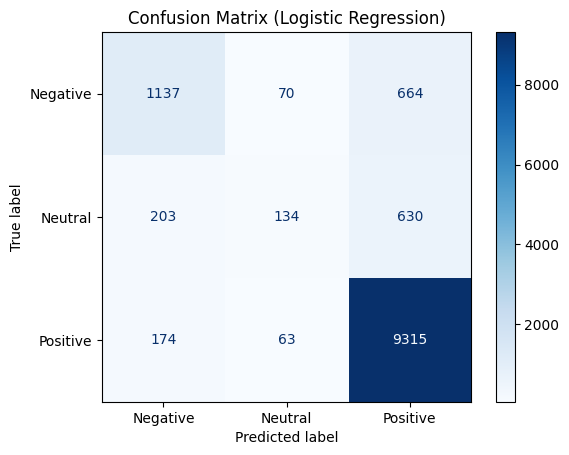

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("\n--- Step 8: Evaluation Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Plotting the Confusion Matrix
labels_names = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

In [ ]:
# ----------------------------------------------------
# 9️⃣ Live Testing: ا
# ----------------------------------------------------
print("\n--- Step 9: Live Prediction on New Sentences ---")


new_texts = [
    "I don't hate this product at all! Its quality is extremely poor.", # إيجابي متوقع
    "The delivery was late, but the item itself is fine.",         # محايد/سلبي متوقع
    "This service is incredibly slow and disappointing.",           # سلبي متوقع
    "It's just okay, nothing special to write home about."         # محايد متوقع
]

# دالة لتحويل التنبؤ الرقمي إلى اسم الفئة
def convert_prediction_to_label(pred):
    if pred == 2:
        return "Positive (إيجابي)"
    elif pred == 1:
        return "Neutral (محايد)"
    else:
        return "Negative (سلبي)"

results = []
for text in new_texts:

    cleaned_text = clean_text_and_remove_stopwords(text)

    text_tfidf = vectorizer.transform([cleaned_text])

    prediction_num = model.predict(text_tfidf)[0]


    prediction_label = convert_prediction_to_label(prediction_num)

    results.append({
        "Original Text": text,
        "Prediction": prediction_label
    })


results_df = pd.DataFrame(results)
print(results_df)


single_test_text = "The user interface is very confusing and hard to navigate."
cleaned_single_text = clean_text_and_remove_stopwords(single_test_text)
single_tfidf = vectorizer.transform([cleaned_single_text])
single_prediction = model.predict(single_tfidf)[0]
single_label = convert_prediction_to_label(single_prediction)

print(f"\nTest Sentence: '{single_test_text}'")
print(f"Model Prediction: {single_label}")


--- Step 9: Live Prediction on New Sentences ---
                                       Original Text       Prediction
0  I don't hate this product at all! Its quality ...  Negative (سلبي)
1  The delivery was late, but the item itself is ...  Neutral (محايد)
2  This service is incredibly slow and disappoint...  Negative (سلبي)
3  It's just okay, nothing special to write home ...  Neutral (محايد)

Test Sentence: 'The user interface is very confusing and hard to navigate.'
Model Prediction: Negative (سلبي)


**Export / Save Files**

In [ ]:
import joblib

# --- Save the trained Model and Vectorizer to files ---
joblib.dump(model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("Files 'model.pkl' and 'vectorizer.pkl' have been saved successfully!")

Files 'model.pkl' and 'vectorizer.pkl' have been saved successfully!


**Step 1: Install Dependencies**

In [ ]:
# Install the necessary libraries:
# 1. Flask: To build the web website.
# 2. pyngrok: To generate a public link for the website.
!pip install flask pyngrok

**Step 2: Create User Interface (HTML & CSS)**

In [ ]:
from flask import Flask
import os
import shutil

app = Flask(__name__)

# --- Force Refresh: Delete old templates and create new one ---
if os.path.exists('templates'):
    shutil.rmtree('templates')
os.makedirs('templates')

# --- New UI: Sea Background + Hover Zoom Effect ---
html_code = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Sentiment Analysis AI</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600&display=swap" rel="stylesheet">
    <style>
        :root {
            --card-bg: rgba(15, 23, 42, 0.65);
            --accent-color: #38bdf8;
            --text-main: #f8fafc;
            --text-dim: #cbd5e1;
        }

        body {
            font-family: 'Inter', sans-serif;
            background-color: #0f172a;
            background-image: url('https://images.unsplash.com/photo-1468581264429-2548ef9eb732?q=80&w=2070&auto=format&fit=crop');
            background-size: cover;
            background-position: center;
            background-repeat: no-repeat;
            background-attachment: fixed;
            color: var(--text-main);
            height: 100vh;
            margin: 0;
            display: flex;
            align-items: center;
            justify-content: center;
            overflow: hidden;
        }

        body::after {
            content: '';
            position: absolute;
            top: 0; left: 0; right: 0; bottom: 0;
            background: rgba(0, 0, 0, 0.3);
            z-index: -1;
        }

        .container {
            background: var(--card-bg);
            backdrop-filter: blur(12px);
            -webkit-backdrop-filter: blur(12px);
            padding: 45px;
            border-radius: 28px;
            border: 1px solid rgba(255, 255, 255, 0.2);
            box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.6);
            width: 90%;
            max-width: 500px;
            text-align: center;
            transition: transform 0.4s ease, box-shadow 0.4s ease;
        }

        .container:hover {
            transform: scale(1.03);
            box-shadow: 0 30px 60px -10px rgba(0, 0, 0, 0.8);
            border-color: rgba(56, 189, 248, 0.5);
        }

        h1 {
            font-size: 34px;
            font-weight: 700;
            margin-bottom: 10px;
            background: linear-gradient(to right, #e0f2fe, #38bdf8);
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
            text-shadow: 0 4px 12px rgba(0,0,0,0.3);
        }

        p { color: var(--text-dim); font-size: 15px; margin-bottom: 30px; letter-spacing: 0.5px; }

        textarea {
            width: 100%; height: 130px; padding: 20px;
            border: 1px solid rgba(255, 255, 255, 0.2);
            border-radius: 18px; font-size: 16px;
            background: rgba(0, 0, 0, 0.3); color: white;
            outline: none; box-sizing: border-box; resize: none;
            transition: all 0.3s ease;
        }

        textarea:focus {
            border-color: var(--accent-color);
            background: rgba(0, 0, 0, 0.5);
            box-shadow: 0 0 20px rgba(56, 189, 248, 0.2);
        }

        button {
            width: 100%; padding: 16px; margin-top: 25px;
            background: var(--accent-color); color: #0f172a;
            border: none; border-radius: 14px;
            font-size: 17px; font-weight: 700; cursor: pointer;
            transition: all 0.3s ease;
            text-transform: uppercase;
            letter-spacing: 1px;
        }

        button:hover {
            transform: translateY(-2px);
            box-shadow: 0 10px 25px rgba(56, 189, 248, 0.4);
            filter: brightness(1.1);
        }

        .result-box {
            margin-top: 25px; padding: 18px;
            border-radius: 14px; font-weight: 600; font-size: 18px;
            animation: fadeIn 0.5s ease-out;
            border: 1px solid rgba(255,255,255,0.1);
            text-shadow: 0 2px 4px rgba(0,0,0,0.2);
        }

        @keyframes fadeIn { from { opacity: 0; transform: translateY(10px); } to { opacity: 1; } }

        .footer { margin-top: 35px; font-size: 12px; color: rgba(255,255,255,0.4); letter-spacing: 2px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Sentiment AI</h1>
        <p>AI-Powered Text Analysis System</p>
        <form method="POST">
            <textarea name="user_text" placeholder="Paste your text here to detect its sentiment..." required>{{ old_text }}</textarea>
            <button type="submit">Analyze</button>
        </form>
        {% if result %}
        <div class="result-box" style="background-color: {{ bg_color }}; color: {{ text_color }};">
            {{ result }}
        </div>
        {% endif %}
        <div class="footer">Powered by NLP & Flask</div>
    </div>
</body>
</html>
"""
# Save the HTML content to index.html
with open('templates/index.html', 'w') as f:
    f.write(html_code)

print("Template updated successfully")

Template updated successfully


**Step 3: Backend Logic (Flask App)**

In [ ]:
from flask import Flask, render_template, request
from pyngrok import ngrok
import joblib
import os

app = Flask(__name__)

# --- Load saved files from Cell 2 ---
final_model = joblib.load('model.pkl')
final_vectorizer = joblib.load('vectorizer.pkl')

def predict_sentiment_live(text):
    # Process text using the function defined in Cell 1
    cleaned = clean_text_and_remove_stopwords(text)
    vec = final_vectorizer.transform([cleaned])
    pred = final_model.predict(vec)[0]

    # 0: Negative, 1: Neutral, 2: Positive
    if pred == 2: return "Positive", "#d1e7dd", "#0f5132"
    elif pred == 1: return "Neutral", "#fff3cd", "#664d03"
    else: return "Negative", "#f8d7da", "#842029"

@app.route('/', methods=['GET', 'POST'])
def home():
    res, bg, tc = "", "transparent", "white"
    user_input = ""

    if request.method == 'POST':
        user_input = request.form['user_text']
        res, bg, tc = predict_sentiment_live(user_input)

    return render_template('index.html', result=res, bg_color=bg, text_color=tc, old_text=user_input)

# --- Start Server ---
my_token = "36hyN6P5c6hGqIzOKRjdUhd8Sjl_85iQf66ux3ha57uZFYn4y"
ngrok.set_auth_token(my_token)
ngrok.kill()
public_url = ngrok.connect(5000).public_url
print(f"Live URL: {public_url}")
app.run(port=5000)

Live URL: https://emmitt-tartaric-milan.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [17/Dec/2025 21:14:21] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Dec/2025 21:14:47] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Dec/2025 21:15:06] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Dec/2025 21:15:20] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Dec/2025 21:15:33] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Dec/2025 21:15:49] "POST / HTTP/1.1" 200 -
